## LSO summer internship 2026

note: *the author is not pro in sunpy/wcs, so there might be mistakes, maybe even obvious ones* - Đ. M.

In [20]:
import numpy as np
from scipy.io import readsav
from scipy.ndimage import gaussian_filter
from scipy.optimize import curve_fit, least_squares
from matplotlib import pyplot as plt 
from astropy.io import fits
import sunpy.map
from astropy import units as u
import warnings

warnings.filterwarnings("ignore", category=UserWarning, module="astropy.io.fits")
warnings.filterwarnings("ignore", module="sunpy.map")

#### **Handling FITS files from observations and plotting** 

Same `CRPIX` and same `CRVAL` - across two different days, two position angles, two cameras (possibly two binnings), two limbs. The pointing translation

must differ between observations. It isn't encoded anywhere in `CRPIX` or `CRVAL`, and no angle keyword can supply a translation.

In [21]:
print('Interpretation from above:')
for f in ["lso_comp-s_lev4.1_20221102_090718_wave0656_pa023_obse.fits",
          "lso_comp-s_lev1.0_20260524_071644_wave0656_pa040_cam2_obse.fits"]:
    h = fits.open(f)[2].header
    print(h['CRPIX1'], h['CRPIX2'], h['CRVAL1'], h['CRVAL2'])

Interpretation from above:
640.5 270.5 0.0 0.2777777910232544
640.5 270.5 0.0 0.2777777910232544


Attempt to plot correctly.

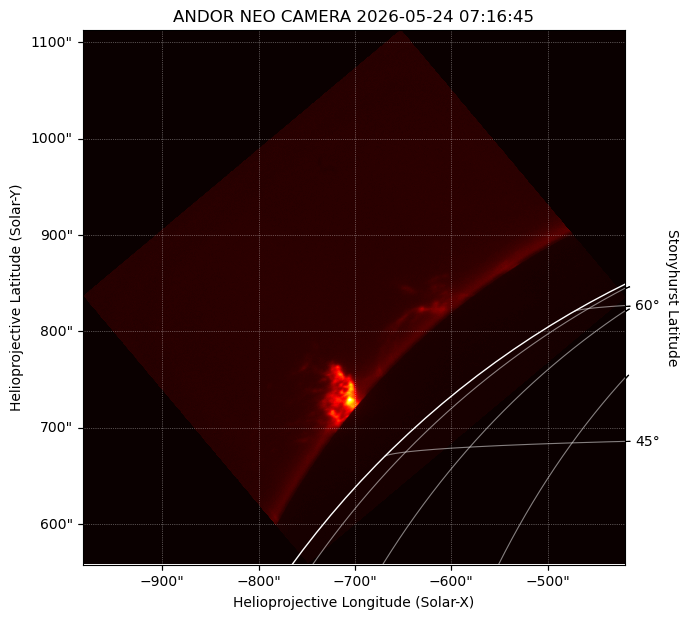

In [22]:
w0656 = fits.open("lso_comp-s_lev1.0_20260524_071644_wave0656_pa040_cam2_obse.fits")

d = w0656[2].data[0]
hdr = w0656[2].header.copy()
ny, nx = d.shape

R = np.array([[hdr["PC1_1"], hdr["PC1_2"]], [hdr["PC2_1"], hdr["PC2_2"]]])
hdr['CRVAL1'], hdr['CRVAL2'] = R @ [hdr['CRVAL1'], hdr['CRVAL2']]

m = sunpy.map.Map(d, hdr).rotate(order=3, missing=0)
m = sunpy.map.Map(d, hdr).rotate(order=3, missing=0)
fig = plt.figure(figsize=(7, 7))
ax = fig.add_subplot(projection=m)
m.plot(axes=ax, cmap='hot')
m.draw_limb(axes=ax, color='white')
m.draw_grid(axes=ax)
plt.show()

---

#### **Alternative**

The fit slides a circle of known solar radius $R_\text{pix}$ until it threads through the bright limb pixels $(x_s, y_s)$, finding the disk-center pixel $(x_c, y_c)$ that minimizes this:

$$
\sum_s \left( \sqrt{(x_s - c_x)^2 + (y_s - c_y)^2} - R_\text{pix} \right)^2.
$$

But this is probably not acceptable.

Set MJD-OBS to 61184.303302 from DATE-OBS.
Set MJD-BEG to 61184.303302 from DATE-BEG.
Set MJD-END to 61184.303305 from DATE-END'. [astropy.wcs.wcs]
Set OBSGEO-B to    49.195149 from OBSGEO-[XYZ].
Set OBSGEO-H to     2673.984 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]


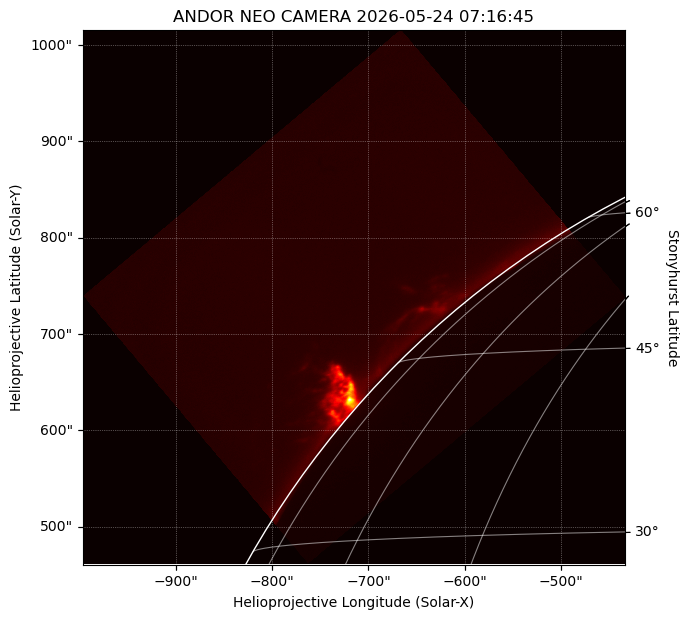

In [23]:
img = np.asarray(w0656[9].data[0], dtype=float) # far line wing, where the disk is bright and the off-limb sky is dark, so the limb is a clean edge to fit
cdelt = hdr['CDELT1'] * 3600 # arcsec/px
Rpix = hdr['RSUN_ARC'] / cdelt # solar radius in pixels

gmag = np.hypot(*np.gradient(gaussian_filter(img, 3))) # smooth the image slightly, compute the intensity gradient magnitude
ys, xs = np.where(gmag > np.percentile(gmag, 99.5)) # limb is the brightest edge in the frame

xc, yc = WCS(hdr).celestial.world_to_pixel_values(0.0, 0.0)
xc, yc = least_squares(lambda c: np.hypot(xs - c[0], ys - c[1]) - Rpix, x0=[xc, yc], loss='soft_l1', f_scale=5.0).x # robust loss; minimization of residuals

hdr['CRPIX1'], hdr['CRPIX2'] = xc + 1.0, yc + 1.0 # true disk center pixel
hdr['CRVAL1'], hdr['CRVAL2'] = 0.0, 0.0 # WCS anchor is tied to a feature measured from data itself

# recommendation - fit on the sharp-limb frame and display whatever frame is actually needed!
img_show = np.asarray(w0656[2].data[0], dtype=float)
m = sunpy.map.Map(img_show, hdr).rotate(order=3, missing=0)
fig = plt.figure(figsize=(7, 7))
ax = fig.add_subplot(projection=m)
m.plot(axes=ax, cmap='hot')
m.draw_limb(axes=ax, color='white')
m.draw_grid(axes=ax)
plt.show()